Critical note for PSO in Week 3: the thermal signals have memory. The current temperature depends on all previous loading history, not just the current operating point. Your PSO objective function must account for this - you cannot treat each timestep independently.

since i_q and torque are perfectly correlated, if your simulator produces accurate i_q it will automatically produce accurate torque

# PMSM Electric Motor - Exploratory Data Analysis

## Basic Dataset Info
Goal: Confirm data loaded correctly, check for nulls, and understand the range of every signal.

Columns:
- Inputs (control): u_d, u_q, i_d, i_q
- Outputs (to predict): motor_speed, torque
- Thermal (PSO parameters later): coolant, ambient, pm, stator_winding, stator_tooth, stator_yoke
- Grouping: profile_id

Sample rate: 2 Hz (one row = 0.5 seconds)

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    '/Users/vaishnaviraghupathi/Desktop/pmsm-digital-twin/pmsm-digital-twin/data/measures_v2.csv'
)

print("Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistics:\n", df.describe().round(3))

Shape: (1330816, 13)

Column Types:
 u_q               float64
coolant           float64
stator_winding    float64
u_d               float64
stator_tooth      float64
motor_speed       float64
i_d               float64
i_q               float64
pm                float64
stator_yoke       float64
ambient           float64
torque            float64
profile_id          int64
dtype: object

Missing Values:
 u_q               0
coolant           0
stator_winding    0
u_d               0
stator_tooth      0
motor_speed       0
i_d               0
i_q               0
pm                0
stator_yoke       0
ambient           0
torque            0
profile_id        0
dtype: int64

Statistics:
                u_q      coolant  stator_winding          u_d  stator_tooth  \
count  1330816.000  1330816.000     1330816.000  1330816.000   1330816.000   
mean        54.279       36.230          66.343      -25.134        56.879   
std         44.173       21.786          28.672       63.092        22.9

## Profile Analysis
Goal: Understand how many measurement sessions exist, how long each one is,
and whether profiles differ in their operating conditions.

Each profile is one continuous test run on the motor bench.
Profile length matters because thermal signals drift slowly over time.

## Note - Excluded Profiles

Profile 2 and Profile 3 are excluded from all further analysis.

Reason: Both show a constant speed_mean of 100 rpm and very low temp_max
(46C and 29C respectively), indicating bench calibration or warmup runs.
They do not represent real driving cycles and would bias the model.

All further analysis uses df_clean.

In [3]:
profile_stats = df.groupby('profile_id').agg(
    samples=('profile_id', 'count'),
    duration_min=('profile_id', lambda x: len(x) * 0.5 / 60),
    speed_mean=('motor_speed', 'mean'),
    torque_mean=('torque', 'mean'),
    temp_max=('pm', 'max')
).round(2)

print("Total profiles:", df['profile_id'].nunique())
print("Total duration (hours):", round(df.shape[0] * 0.5 / 3600, 1))
print("\nPer-profile summary:")
print(profile_stats.to_string())

excluded = [2, 3]
df_clean = df[~df['profile_id'].isin(excluded)].reset_index(drop=True)
print("\ndf_clean shape:", df_clean.shape)

Total profiles: 69
Total duration (hours): 184.8

Per-profile summary:
            samples  duration_min  speed_mean  torque_mean  temp_max
profile_id                                                          
2             19357        161.31      100.00        79.15     45.99
3             19248        160.40      100.00        51.69     29.01
4             33424        278.53     2683.07        32.84     99.40
5             14788        123.23      999.99        43.52     39.94
6             40388        336.57     3445.31        15.35     93.51
7             14651        122.09      499.59        84.89     35.85
8             18757        156.31     1498.04        53.49     44.29
9             20336        169.47     2496.96        55.73     51.11
10            15256        127.13     1926.08        -2.76     72.08
11             7887         65.72     2115.52        47.81     57.11
12            21942        182.85     1998.11        59.13     47.84
13            35906        299.2

## Signal Plots Per Profile
Goal: Visualise how the control inputs and target outputs behave over time
within each profile. This reveals the nature of the driving cycles and
confirms the motor is being driven through varied operating conditions.

Signals plotted: u_d, u_q, i_d, i_q, motor_speed, torque


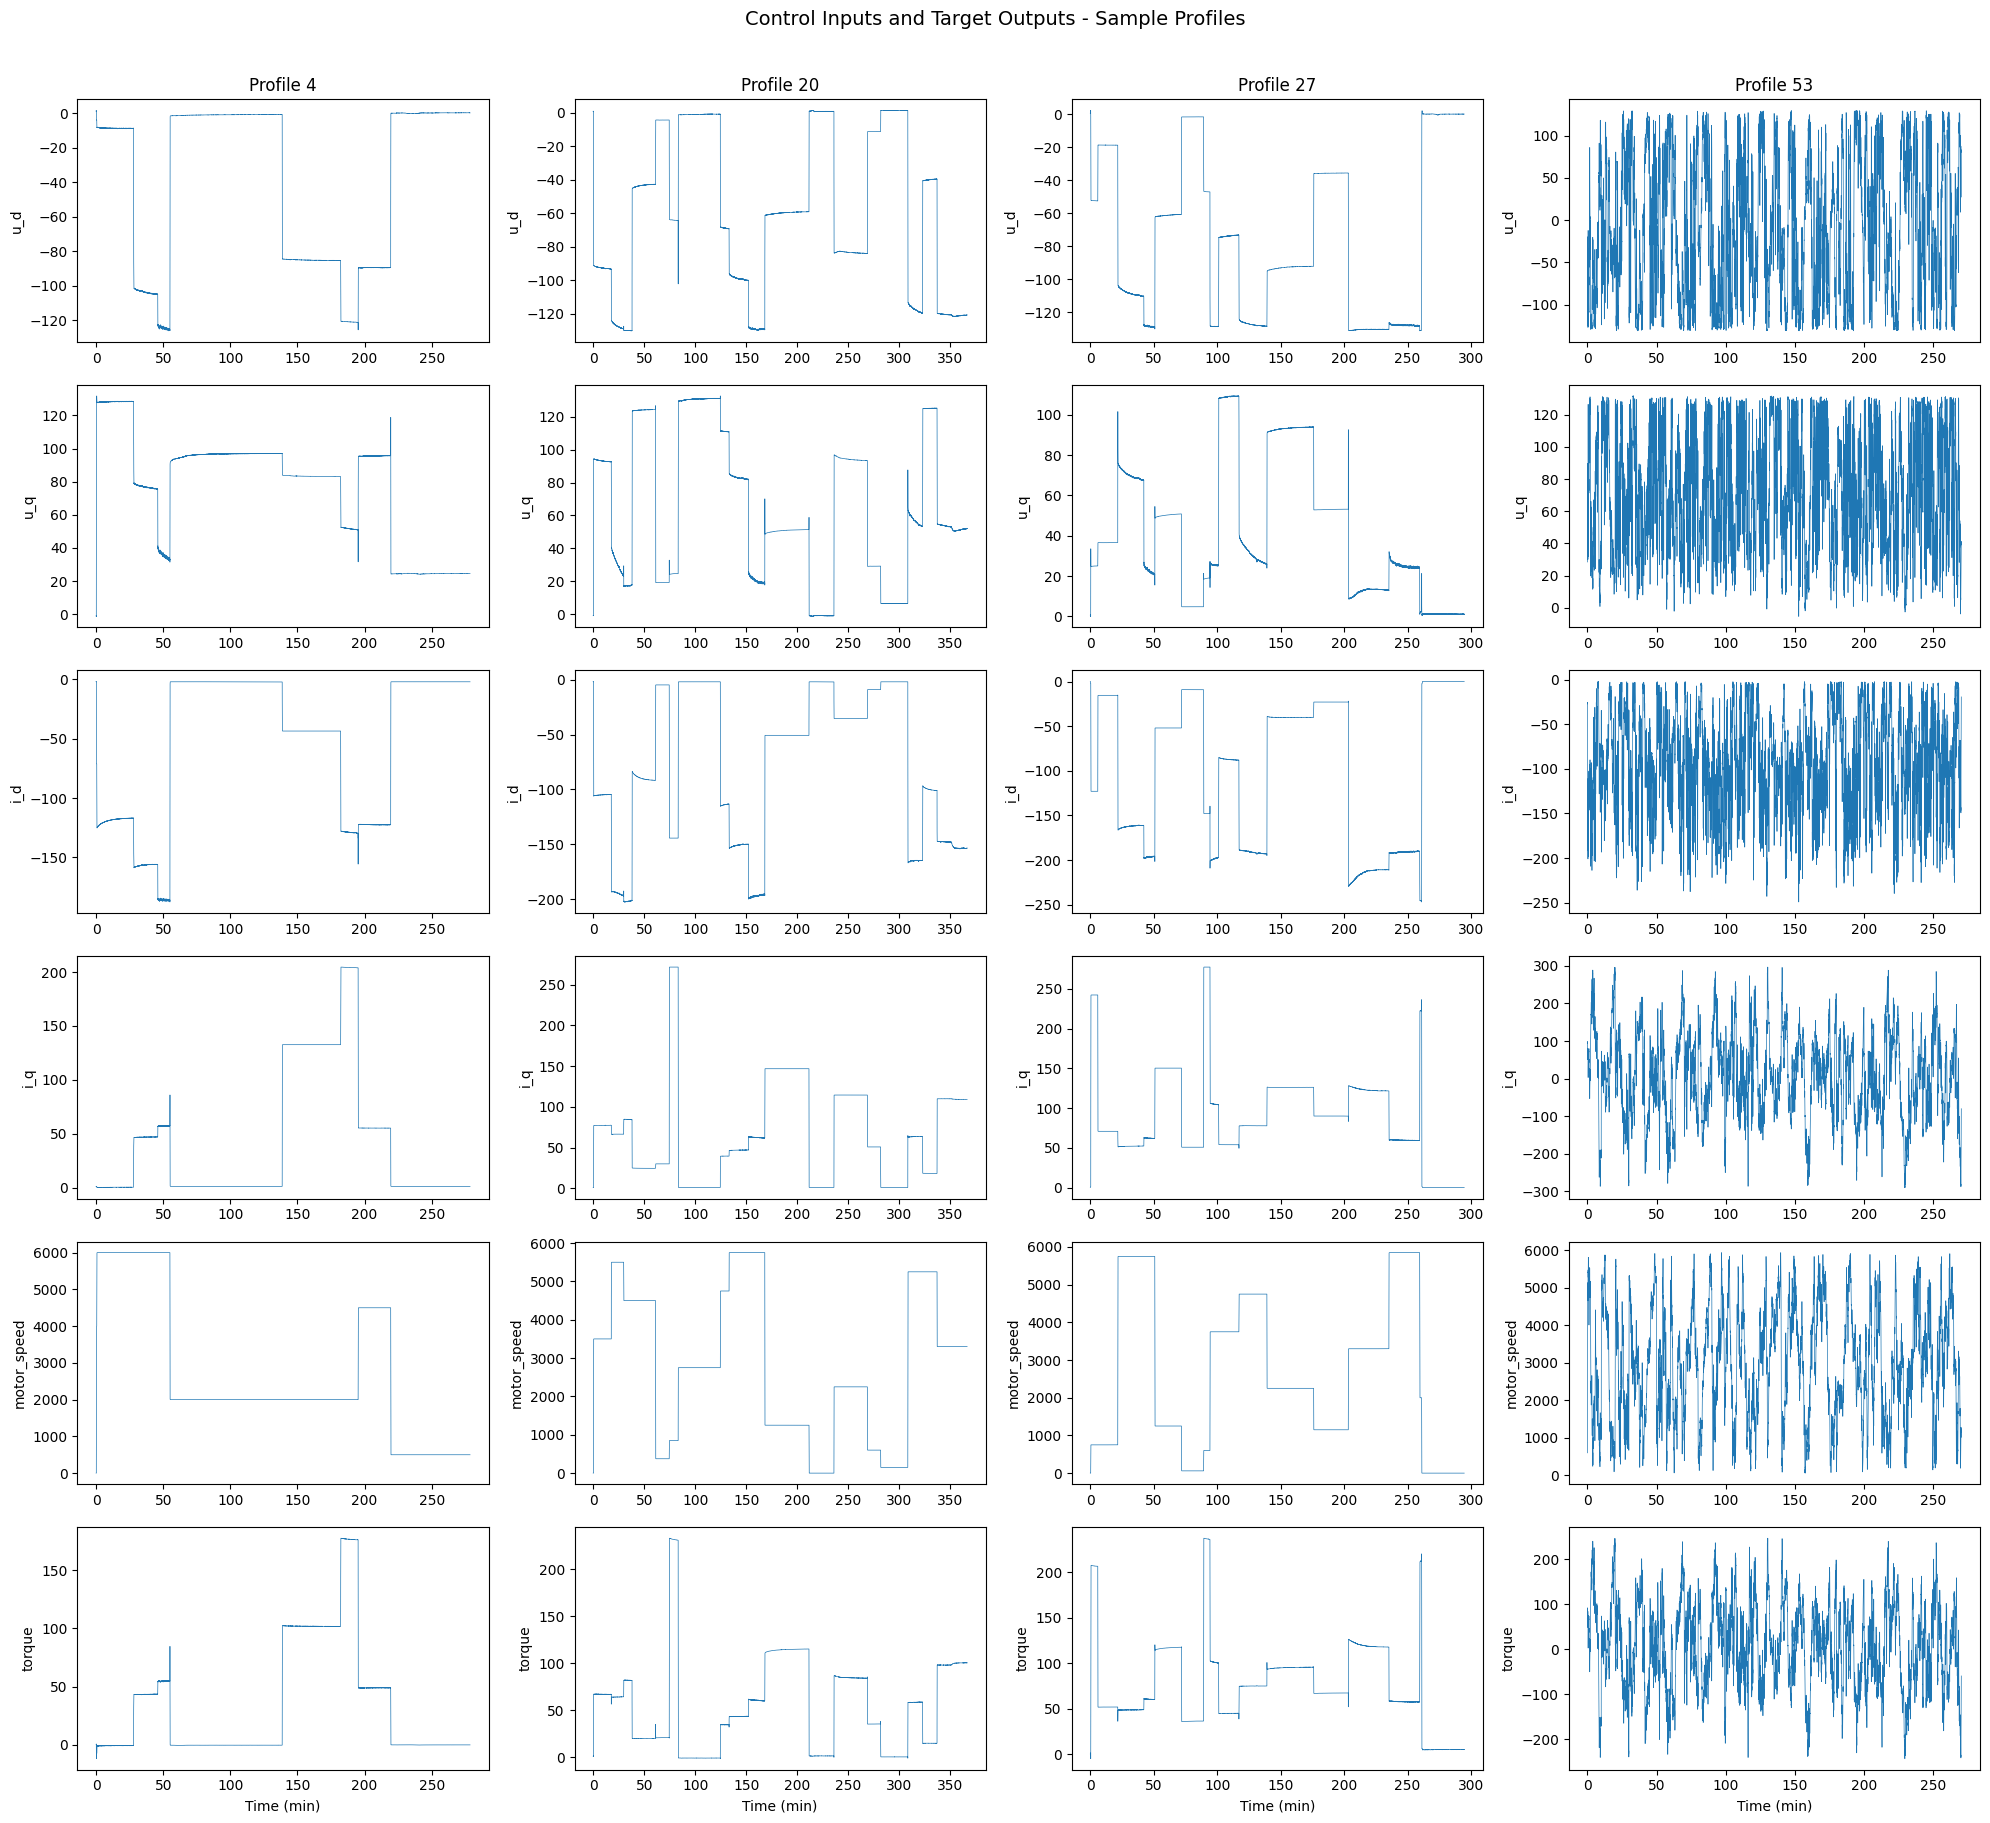

In [4]:
import matplotlib.pyplot as plt

signals = ['u_d', 'u_q', 'i_d', 'i_q', 'motor_speed', 'torque']
sample_profiles = [4, 20, 27, 53]  # short, long, high torque, near-zero torque

fig, axes = plt.subplots(len(signals), len(sample_profiles),
                          figsize=(20, 18), sharex=False)

for col, pid in enumerate(sample_profiles):
    profile_data = df_clean[df_clean['profile_id'] == pid].reset_index(drop=True)
    time = profile_data.index * 0.5 / 60  # convert to minutes

    for row, signal in enumerate(signals):
        axes[row, col].plot(time, profile_data[signal], linewidth=0.5)
        axes[row, col].set_ylabel(signal)
        if row == 0:
            axes[row, col].set_title(f'Profile {pid}')
        if row == len(signals) - 1:
            axes[row, col].set_xlabel('Time (min)')

plt.suptitle('Control Inputs and Target Outputs - Sample Profiles',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Thermal Signal Plots Per Profile
Goal: Understand how temperatures evolve over time within each session.
Thermal signals are slow-moving and cumulative, they reflect the heat
buildup from electrical losses over the entire session duration.

Signals plotted: coolant, ambient, pm, stator_winding, stator_tooth, stator_yoke


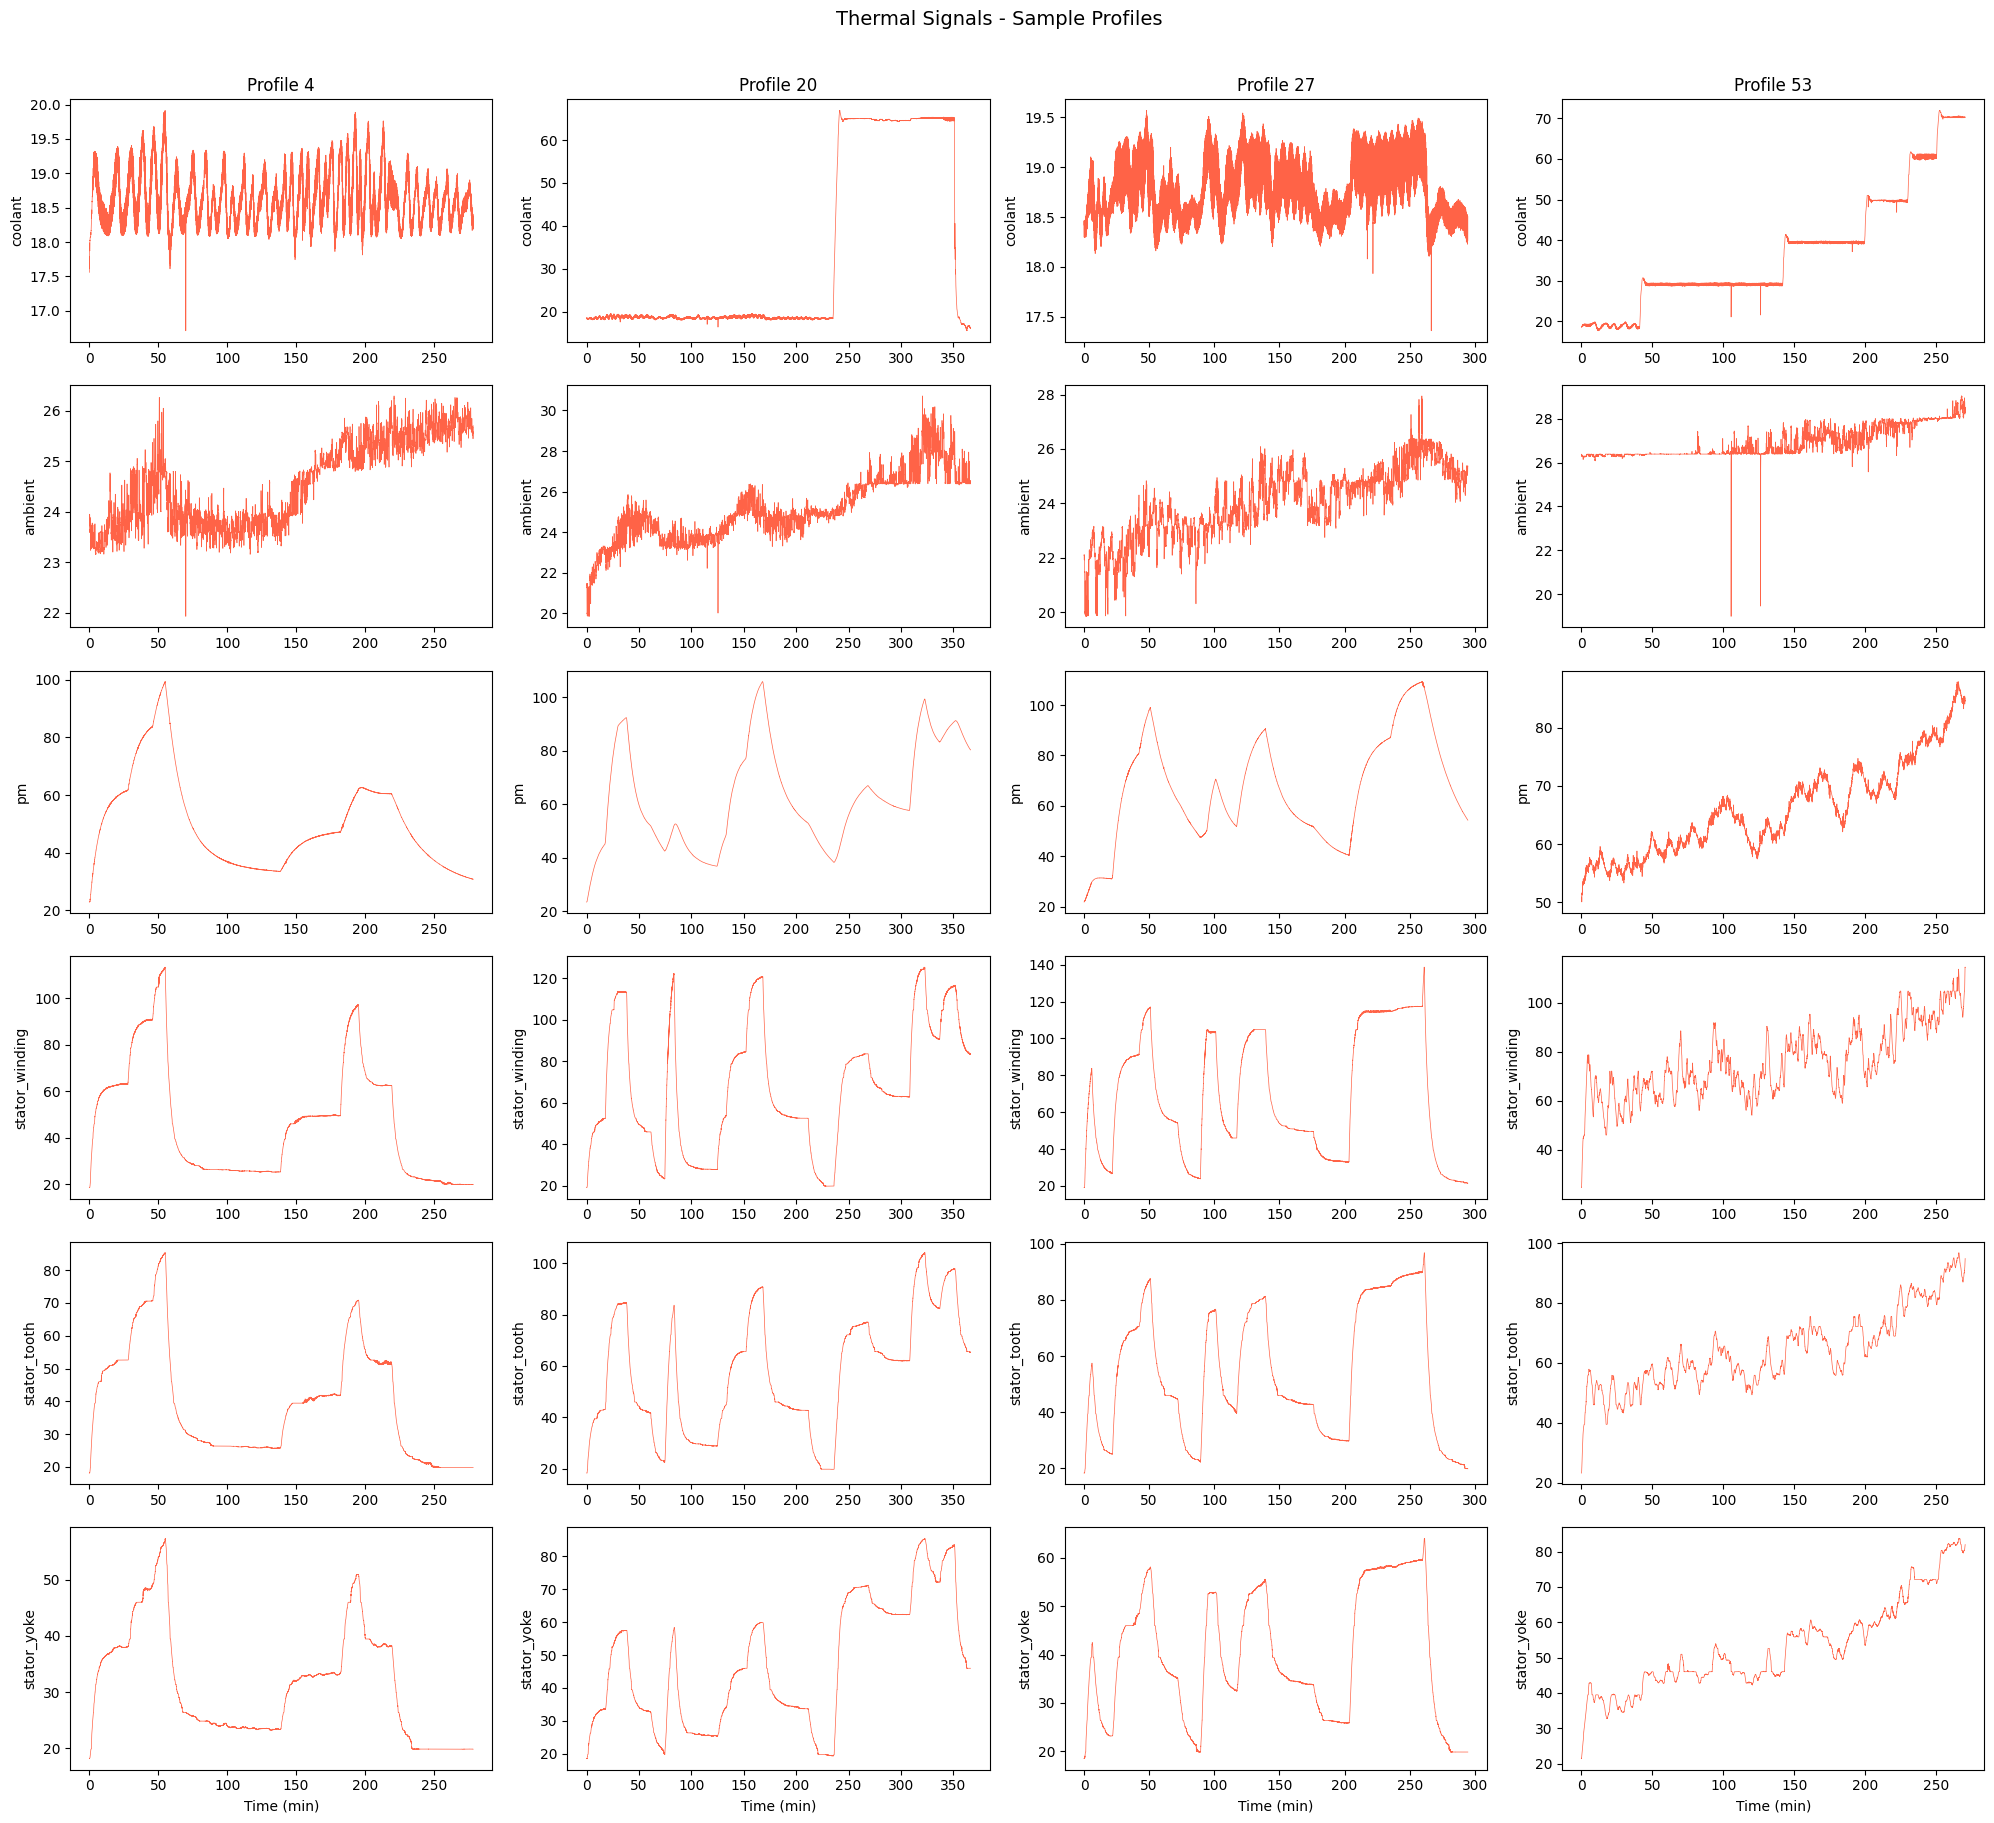

In [5]:
thermal_signals = ['coolant', 'ambient', 'pm', 'stator_winding', 'stator_tooth', 'stator_yoke']
sample_profiles = [4, 20, 27, 53]

fig, axes = plt.subplots(len(thermal_signals), len(sample_profiles),
                          figsize=(20, 18), sharex=False)

for col, pid in enumerate(sample_profiles):
    profile_data = df_clean[df_clean['profile_id'] == pid].reset_index(drop=True)
    time = profile_data.index * 0.5 / 60

    for row, signal in enumerate(thermal_signals):
        axes[row, col].plot(time, profile_data[signal], linewidth=0.5, color='tomato')
        axes[row, col].set_ylabel(signal)
        if row == 0:
            axes[row, col].set_title(f'Profile {pid}')
        if row == len(thermal_signals) - 1:
            axes[row, col].set_xlabel('Time (min)')

plt.suptitle('Thermal Signals - Sample Profiles', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Signal Distributions
Goal: Understand the statistical spread of every signal across the full dataset.
This reveals skewness, multimodality, and whether any signal is dominated
by a single operating point.

Multimodal distributions indicate the motor operates in distinct regimes.

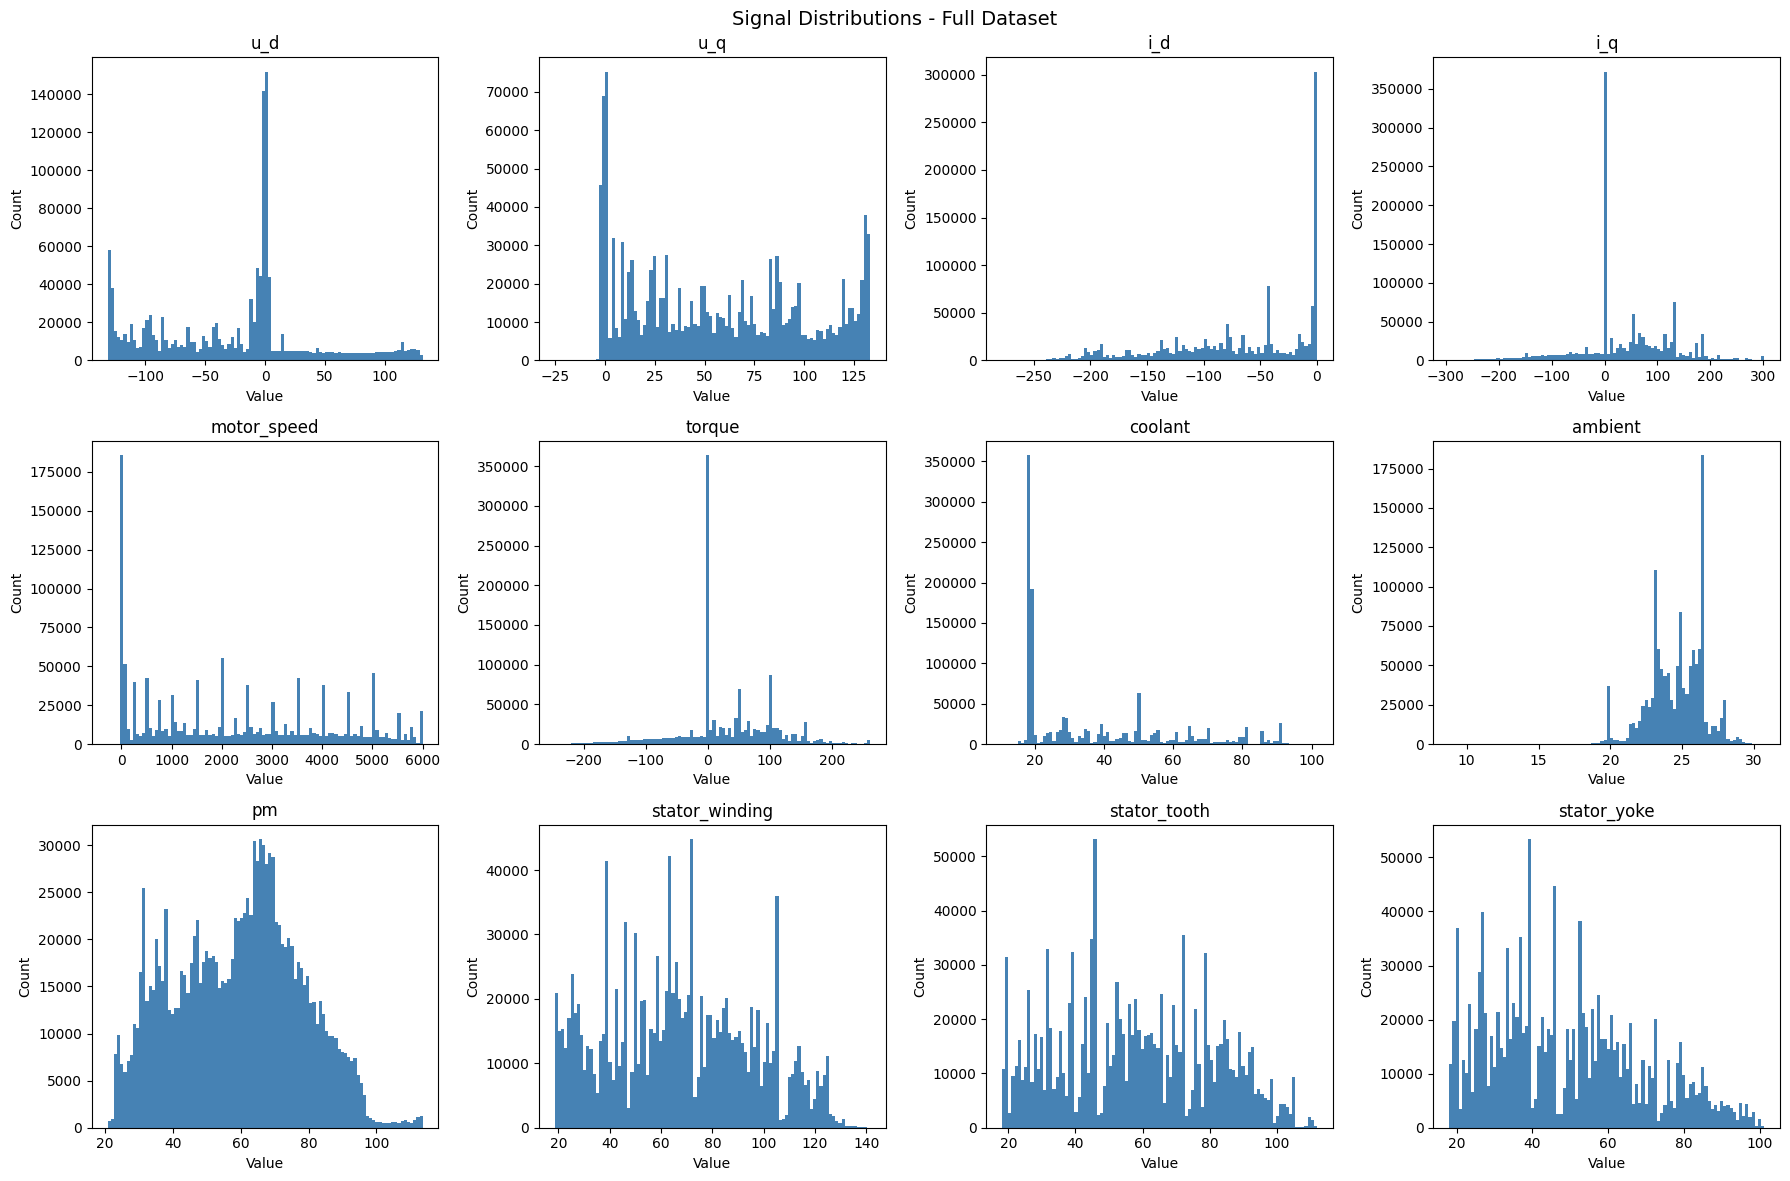

In [6]:
import matplotlib.pyplot as plt

all_signals = ['u_d', 'u_q', 'i_d', 'i_q', 'motor_speed', 'torque',
               'coolant', 'ambient', 'pm', 'stator_winding', 'stator_tooth', 'stator_yoke']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, signal in enumerate(all_signals):
    axes[idx].hist(df_clean[signal], bins=100, color='steelblue', edgecolor='none')
    axes[idx].set_title(signal)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Count')

plt.suptitle('Signal Distributions - Full Dataset', fontsize=14)
plt.tight_layout()
plt.show()

## Correlation Heatmap
Goal: Quantify linear relationships between all signals.
This confirms which inputs drive which outputs and reveals
redundancy between signals.

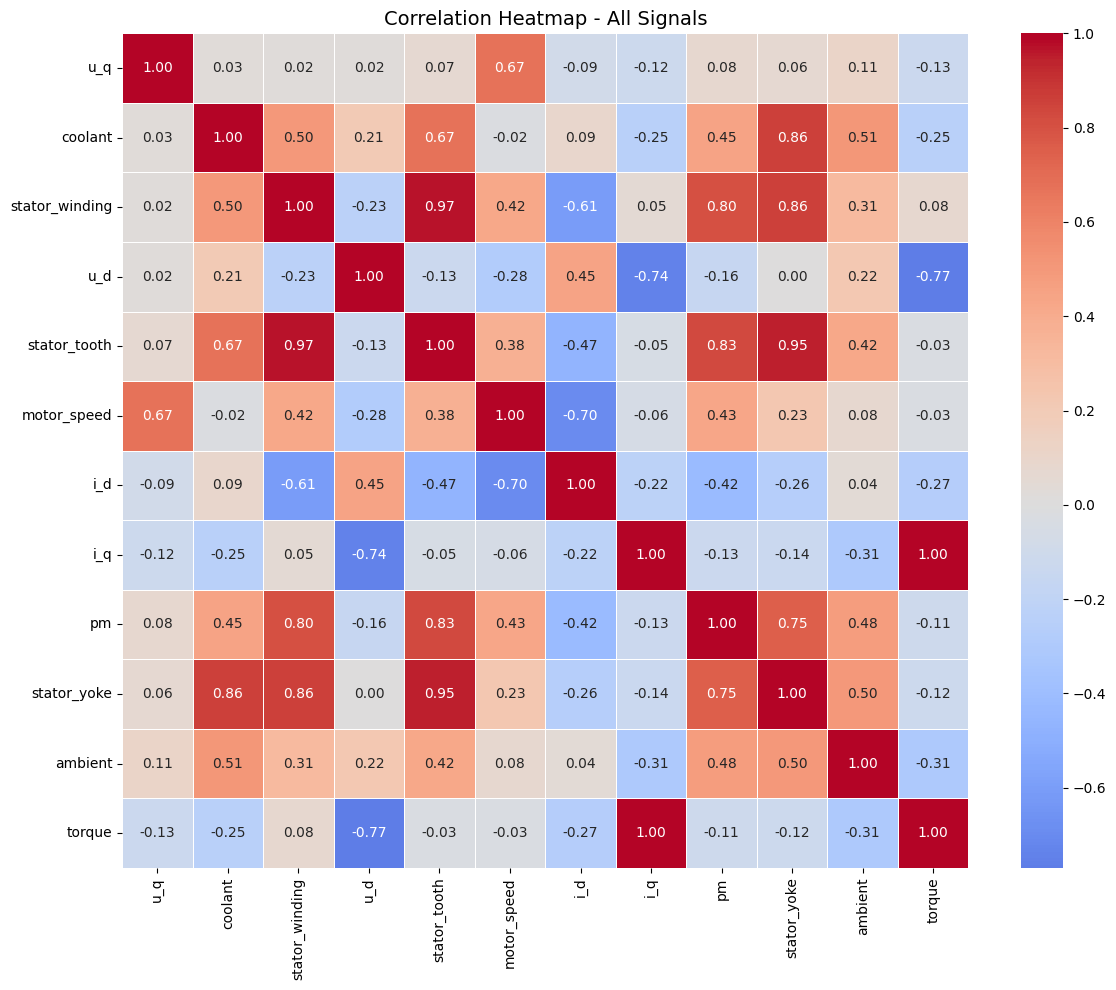

In [14]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 10))

corr = df_clean.drop(columns='profile_id').corr().round(2)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)

ax.set_title('Correlation Heatmap - All Signals', fontsize=14)
plt.tight_layout()

plt.savefig('/Users/vaishnaviraghupathi/Desktop/heatmap.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Speed-Torque Operating Plane
Goal: Visualise the full operating space of the motor across all profiles.
This is the control space your simulator must be able to reproduce.
A well-covered operating plane means the dataset is suitable for generalisation.

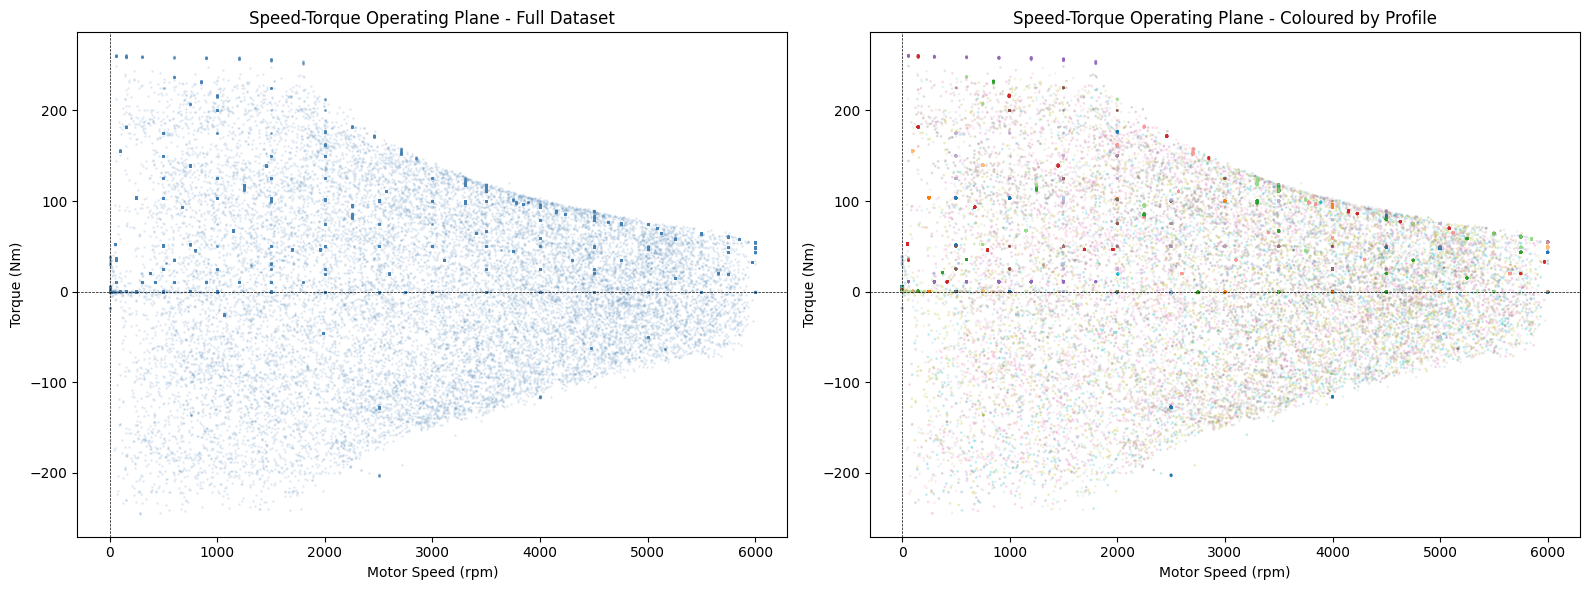

In [11]:
# sample to avoid overplotting
sample = df_clean.sample(n=50000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# full dataset operating plane
axes[0].scatter(sample['motor_speed'], sample['torque'],
                alpha=0.1, s=1, color='steelblue')
axes[0].set_xlabel('Motor Speed (rpm)')
axes[0].set_ylabel('Torque (Nm)')
axes[0].set_title('Speed-Torque Operating Plane - Full Dataset')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].axvline(0, color='black', linewidth=0.5, linestyle='--')

# coloured by profile to see coverage per session
scatter = axes[1].scatter(sample['motor_speed'], sample['torque'],
                           c=sample['profile_id'], cmap='tab20',
                           alpha=0.2, s=1)
axes[1].set_xlabel('Motor Speed (rpm)')
axes[1].set_ylabel('Torque (Nm)')
axes[1].set_title('Speed-Torque Operating Plane - Coloured by Profile')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].axvline(0, color='black', linewidth=0.5, linestyle='--')

plt.savefig('/Users/vaishnaviraghupathi/Desktop/speed-torque operating plane.pdf', bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

## Cross-Signal Relationships
Goal: Visualise the key physically meaningful signal pairs identified
from the correlation heatmap. These relationships will directly
inform how the simulator models the motor dynamics.

Pairs examined:
- i_q vs torque (torque production)
- i_d vs motor_speed (field weakening)
- u_q vs motor_speed (voltage-speed relationship)
- u_d vs i_q (cross-coupling effect)

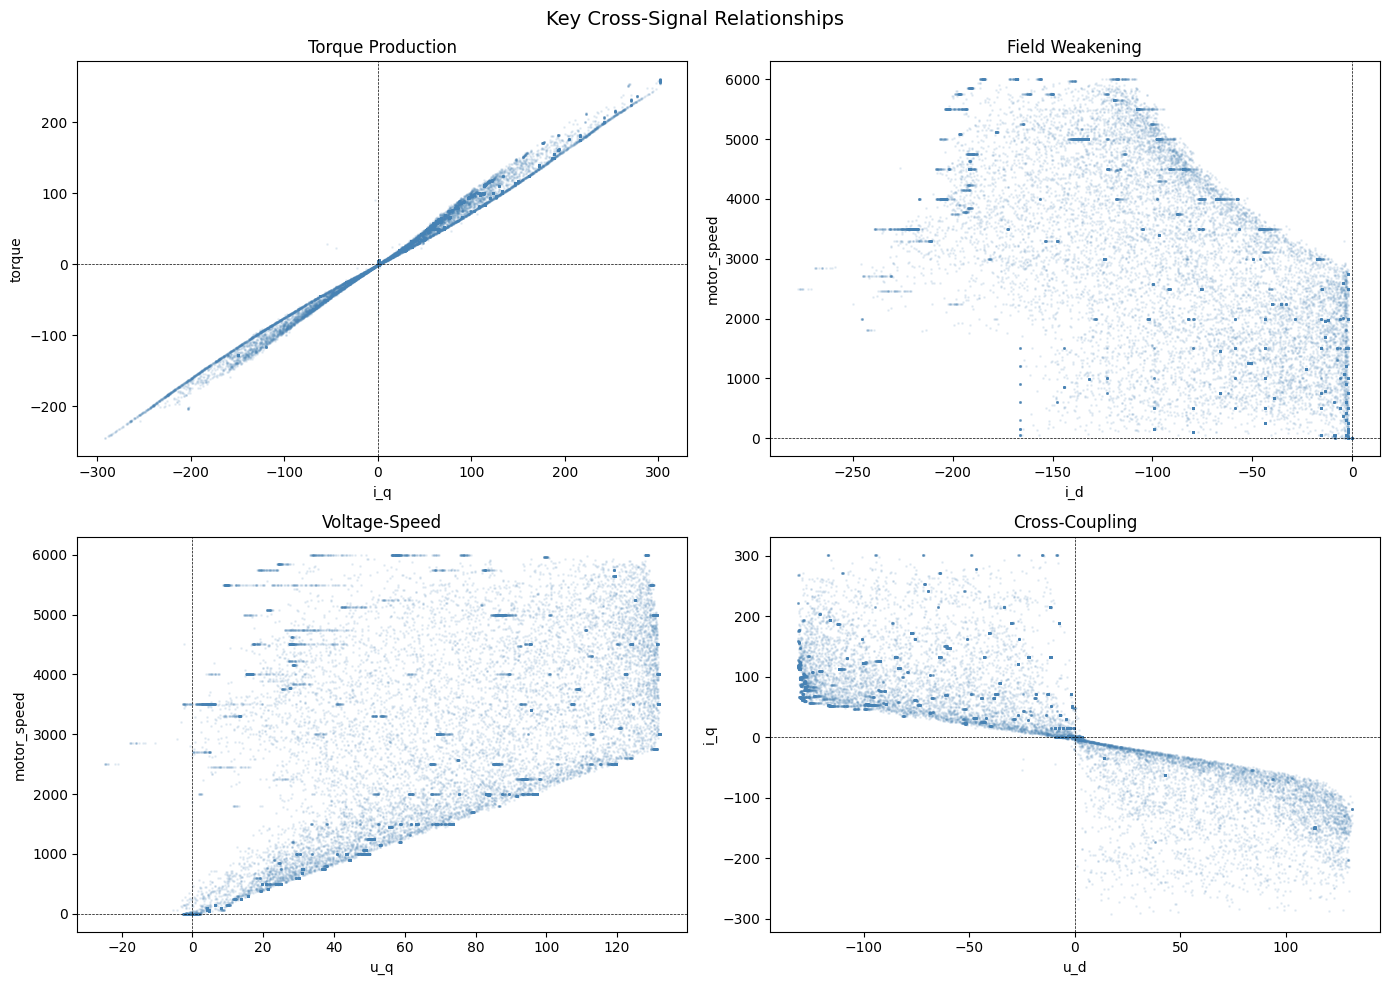

In [17]:
sample = df_clean.sample(n=30000, random_state=42)

pairs = [
    ('i_q', 'torque', 'Torque Production'),
    ('i_d', 'motor_speed', 'Field Weakening'),
    ('u_q', 'motor_speed', 'Voltage-Speed'),
    ('u_d', 'i_q', 'Cross-Coupling')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (x, y, title) in enumerate(pairs):
    axes[idx].scatter(sample[x], sample[y], alpha=0.1, s=1, color='steelblue')
    axes[idx].set_xlabel(x)
    axes[idx].set_ylabel(y)
    axes[idx].set_title(title)
    axes[idx].axhline(0, color='black', linewidth=0.5, linestyle='--')
    axes[idx].axvline(0, color='black', linewidth=0.5, linestyle='--')

plt.suptitle('Key Cross-Signal Relationships', fontsize=14)
plt.tight_layout()
plt.show()

## Thermal Lag Analysis
Goal: Visualise how temperature responds to changes in load.
Thermal signals are not instantaneous, they lag behind the electrical
signals that cause them. Understanding this lag is critical for the
PSO parameter estimation in Week 3.


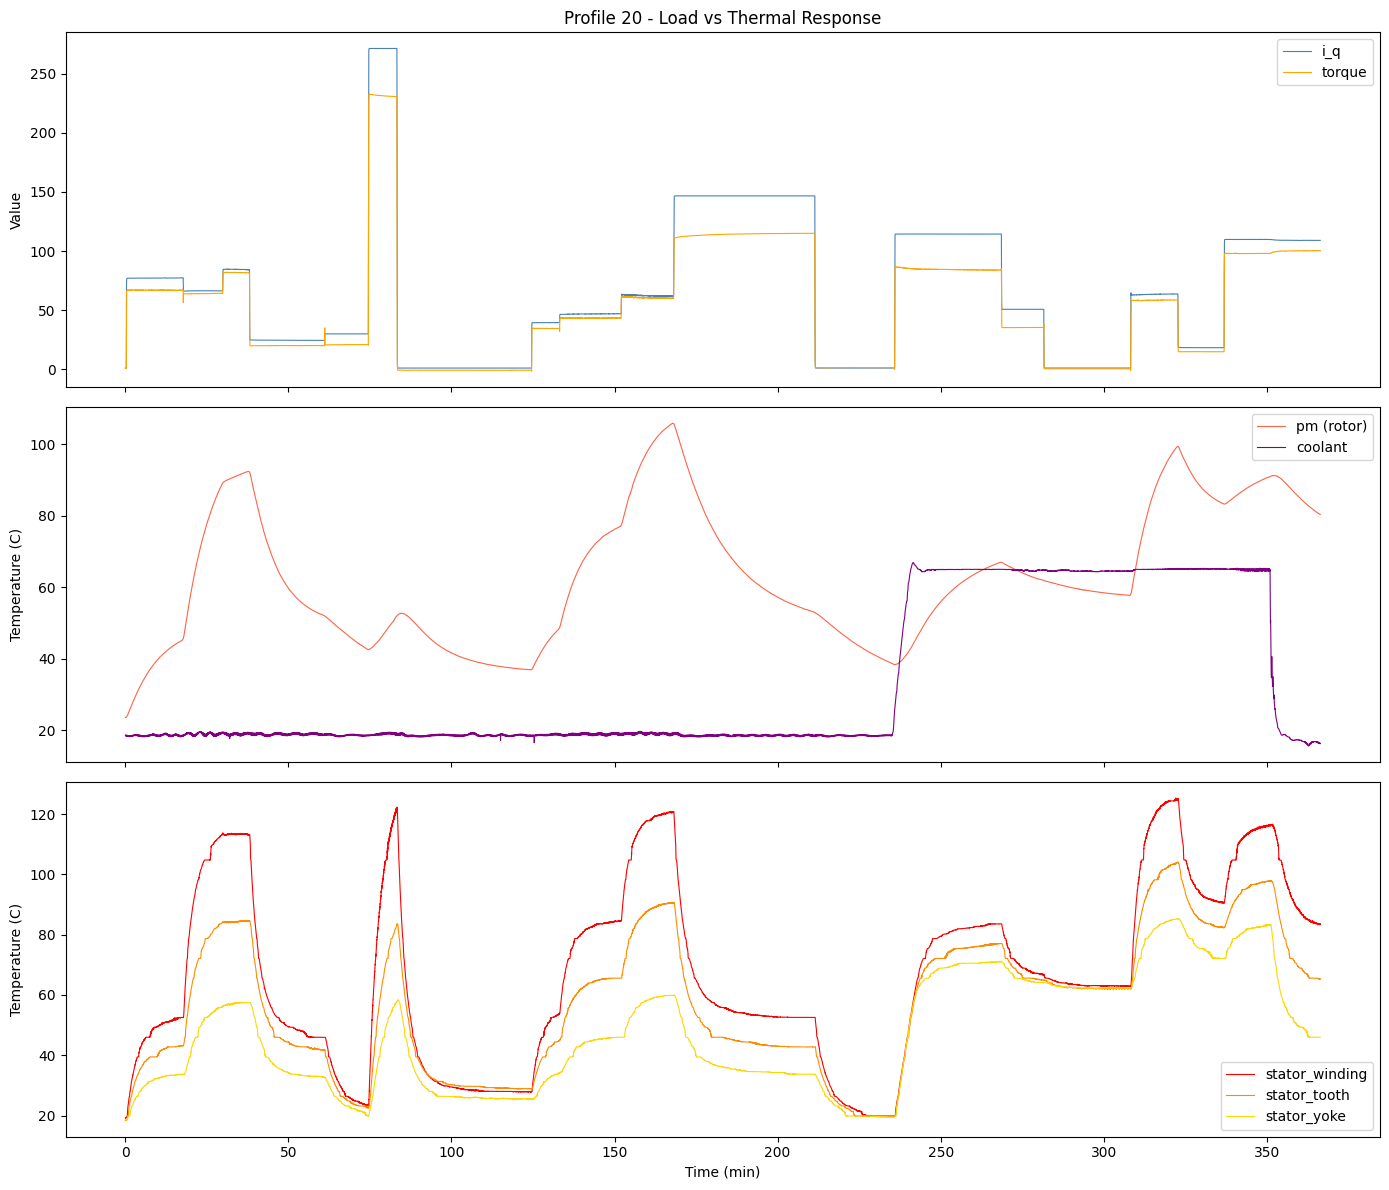

In [18]:
# use a single long profile with clear load steps
pid = 20
profile_data = df_clean[df_clean['profile_id'] == pid].reset_index(drop=True)
time = profile_data.index * 0.5 / 60

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# load signals
axes[0].plot(time, profile_data['i_q'], color='steelblue', linewidth=0.8, label='i_q')
axes[0].plot(time, profile_data['torque'], color='orange', linewidth=0.8, label='torque')
axes[0].set_ylabel('Value')
axes[0].set_title(f'Profile {pid} - Load vs Thermal Response')
axes[0].legend()

# rotor temperature
axes[1].plot(time, profile_data['pm'], color='tomato', linewidth=0.8, label='pm (rotor)')
axes[1].plot(time, profile_data['coolant'], color='purple', linewidth=0.8, label='coolant')
axes[1].set_ylabel('Temperature (C)')
axes[1].legend()

# stator temperatures
axes[2].plot(time, profile_data['stator_winding'], color='red', linewidth=0.8, label='stator_winding')
axes[2].plot(time, profile_data['stator_tooth'], color='darkorange', linewidth=0.8, label='stator_tooth')
axes[2].plot(time, profile_data['stator_yoke'], color='gold', linewidth=0.8, label='stator_yoke')
axes[2].set_ylabel('Temperature (C)')
axes[2].set_xlabel('Time (min)')
axes[2].legend()

plt.tight_layout()
plt.show()

## Profile Feature Extraction

We compute a per-profile feature table that captures the key characteristics 
of each of the 69 profiles so we can cluster them by difficulty.

### What each feature tells us

- **duration_min** - how long the test run is. Longer = more thermal buildup = harder.
- **speed_mean / speed_std / speed_max** - average operating speed, how much it varies, 
  and peak. High speed = field weakening territory = harder.
- **torque_mean / torque_std / torque_max** - same but for torque. 
  High variance = dynamic profile = harder.
- **id_min** - minimum d-axis current. If it goes below -50A the motor is in 
  **field weakening** - a nonlinear regime that is significantly harder to simulate accurately.
- **temp_max** - peak magnet temperature. High temp = Rs has drifted significantly 
  from its cold value = parameters are less stable = harder.
- **has_negative_torque** - whether the profile includes braking/regeneration. 
  Bidirectional torque is harder than pure motoring.
- **speed_cv** - coefficient of variation for speed (std/mean). 
  Low = steady step profile. High = random walk. This is the primary easy/hard separator.
- **torque_cv** - same for torque.
- **field_weakening** - boolean flag derived from id_min < -50, 
  marks profiles that enter the nonlinear high-speed regime.

### Goal

The output of this cell is a **difficulty fingerprint** for every profile, 
which we then use to cluster and rank them from easiest to hardest.

In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/vaishnaviraghupathi/Desktop/pmsm-digital-twin/pmsm-digital-twin/data/measures_v2.csv')
df = df[~df['profile_id'].isin([2, 3])]

stats = df.groupby('profile_id').agg(
    samples=('profile_id', 'count'),
    duration_min=('profile_id', lambda x: len(x) * 0.5 / 60),
    speed_mean=('motor_speed', 'mean'),
    speed_std=('motor_speed', 'std'),
    speed_max=('motor_speed', lambda x: x.abs().max()),
    torque_mean=('torque', 'mean'),
    torque_std=('torque', 'std'),
    torque_max=('torque', lambda x: x.abs().max()),
    id_min=('i_d', 'min'),
    temp_max=('pm', 'max'),
    has_negative_torque=('torque', lambda x: (x < -10).any()),
).round(2)

stats['speed_cv'] = (stats['speed_std'] / (stats['speed_mean'].abs() + 1)).round(3)
stats['torque_cv'] = (stats['torque_std'] / (stats['torque_mean'].abs() + 1)).round(3)
stats['field_weakening'] = stats['id_min'] < -50

print(stats.to_string())

            samples  duration_min  speed_mean  speed_std  speed_max  torque_mean  torque_std  torque_max  id_min  temp_max  has_negative_torque  speed_cv  torque_cv  field_weakening
profile_id                                                                                                                                                                           
4             33424        278.53     2683.07    1920.80    6000.02        32.84       49.21      177.27 -187.56     99.40                 True     0.716      1.454             True
5             14788        123.23      999.99       0.01    1000.44        43.52       50.84      103.67  -43.52     39.94                False     0.000      1.142            False
6             40388        336.57     3445.31    1954.06    4999.96        15.35       65.17      203.62 -278.00     93.51                 True     0.567      3.986             True
7             14651        122.09      499.59      13.29     500.02        84.89       39.

## Profile Clustering Methodology

### Why We Need to Cluster

We have 69 profiles and cannot test all of them individually. Instead, we group them
by how physically challenging they are to simulate, so we can validate the digital
twin progressively — starting simple and building confidence before tackling hard cases.

---

### The Three Features We Use

#### 1. `speed_cv` — Coefficient of Variation of Speed

This is `speed_std / speed_mean`. It measures how much the motor speed fluctuates
relative to its average.

- **Low speed_cv (< 0.1):** The motor runs at a roughly constant speed the whole session.
  These are called **step profiles** — the controller sets a target speed and holds it.
  The ODE reaches a steady state quickly and stays there. Easy to simulate.

- **High speed_cv (> 0.8):** Speed is constantly changing — accelerating, decelerating,
  reversing. These are called **random walk profiles**. The ODE never settles,
  transient dynamics dominate, and small parameter errors accumulate over time.
  Hard to simulate.

We use `speed_cv` as the **primary difficulty axis** because speed drives the electrical
frequency (`we = P * wm`), which in turn drives how fast `id` and `iq` change. A constantly
changing speed means the electrical equations are never at rest.

---

#### 2. `field_weakening` — Whether the Motor Operates Above Base Speed

In a PMSM, there is a natural speed limit set by the available voltage. Below this
limit (base speed), you control torque directly via `iq`. Above it, you must inject
**negative `id` current** to reduce the magnetic flux and allow higher speeds — this is
called **field weakening**.

We flag a profile as field weakening if `id_min < -50A`.

Why does this make simulation harder?

- The d-axis and q-axis equations become strongly coupled. A change in `id` affects `iq`
  and vice versa through the cross-coupling terms (`we * Lq * iq` and `we * Ld * id`).
- The electromagnetic torque equation becomes nonlinear because it now depends on
  both `iq` and the product `id * iq` (reluctance torque term).
- The estimated parameters `Ld` and `Lq` matter much more. In the no-field-weakening
  regime, errors in `Ld` have little effect. In field weakening, they directly affect
  how much `id` you need and therefore how much torque you produce.

In plain terms: below base speed, the motor is relatively simple to model.
Above base speed, the physics becomes genuinely nonlinear.

---

#### 3. `has_negative_torque` — Whether the Motor Brakes or Regenerates

A PMSM can operate in two modes:

- **Motoring:** Converts electrical energy to mechanical energy. Torque is positive.
- **Braking / Regeneration:** Converts mechanical energy back to electrical. Torque
  is negative.

When torque crosses zero, the operating quadrant changes. The current references flip
sign, the voltage demands change direction, and the ODE must handle the transition
smoothly. A simulator calibrated only on motoring data will typically fail at this
boundary.

We flag a profile if torque goes below `-10 Nm` at any point.

---

### Why These Three Features and Not Others

We considered all available signals but rejected most:

- **duration_min:** Longer sessions are harder thermally, but we are not modelling
  thermal effects yet. Not useful for clustering at this stage.
- **torque_cv:** Torque and `iq` are perfectly correlated (`corr = 1.0` from EDA).
  Torque variability is already captured indirectly by `speed_cv` and the operating
  regime flags.
- **temp_max:** Relevant later when we add temperature-dependent `Rs`. Not relevant now.
- **torque_max / speed_max:** Absolute magnitudes tell us operating range but not
  dynamics. A profile at constant 6000 rpm is easier than one bouncing between
  0 and 3000 rpm.

`speed_cv`, `field_weakening`, and `has_negative_torque` together capture the three
independent axes of simulation difficulty: **dynamics, nonlinearity, and operating
quadrant**.

---

### Why This Specific Progression

```text
Steady, no field weakening
→ Steady, field weakening
→ Moderate dynamics, field weakening, motoring only
→ Moderate dynamics, field weakening, bidirectional
→ Random walk, full operating range
```

Each step adds exactly one new source of difficulty:

| Step | What is added | Why it is harder |
|------|----------------|-------------------|
| Cluster 1 → 2 | Field weakening | Nonlinear coupling, Ld/Lq sensitivity |
| Cluster 2 → 3 | Speed dynamics | Transients, ODE never settles |
| Cluster 3 → 4 | Negative torque | Quadrant crossing, current sign reversal |
| Cluster 4 → 5 | Full random walk | All of the above simultaneously |

This progression matters because if the simulator fails on cluster 3, we know the
problem is dynamics, not field weakening (already validated in cluster 2) and not
bidirectional torque (not yet introduced). Each cluster acts as a **controlled
experiment** isolating one source of difficulty at a time.

In [20]:
import pandas as pd
import numpy as np

# paste the stats dataframe from the previous cell, then:

def classify_profile(row):
    scv = row['speed_cv']      # use speed_cv as primary classifier
    fw = row['field_weakening']
    neg = row['has_negative_torque']

    if not fw and scv < 0.1:
        return 1, 'Steady, low-speed, no field weakening'
    elif fw and scv < 0.1:
        return 2, 'Steady, high-speed, field weakening'
    elif fw and 0.1 <= scv < 0.8 and not neg:
        return 3, 'Moderate dynamics, field weakening, motoring'
    elif fw and 0.1 <= scv < 0.8 and neg:
        return 4, 'Moderate dynamics, field weakening, bidirectional'
    else:
        return 5, 'Random walk, full operating range'

stats[['cluster', 'description']] = stats.apply(
    lambda r: pd.Series(classify_profile(r)), axis=1
)

print(stats[['duration_min', 'speed_max', 'torque_max', 'field_weakening',
             'has_negative_torque', 'speed_cv', 'torque_cv', 'cluster', 'description']]
      .sort_values(['cluster', 'speed_cv'])
      .to_string())

print("\nCluster counts:")
print(stats['cluster'].value_counts().sort_index())

            duration_min  speed_max  torque_max  field_weakening  has_negative_torque  speed_cv  torque_cv  cluster                                        description
profile_id                                                                                                                                                            
5                 123.23    1000.44      103.67            False                False     0.000      1.142        1              Steady, low-speed, no field weakening
13                299.22     250.04      104.03            False                False     0.020      0.914        1              Steady, low-speed, no field weakening
7                 122.09     500.02      103.67            False                False     0.027      0.460        1              Steady, low-speed, no field weakening
12                182.85    1999.99      103.03            False                False     0.029      0.837        1              Steady, low-speed, no field weakenin

## Profile Clustering Summary

| Cluster | Description | No. of Profiles | Chosen Profile | Why choose that particular profile |
|---|---|---|---|---|
| 1 | Steady speed, low RPM, no field weakening, motoring only | 5 | **7** | Lowest speed (500 rpm), short duration (122 min), cleanest steady-state signal |
| 2 | Steady speed, high RPM, field weakening active, motoring only | 11 | **19** | Shortest duration (87 min) in cluster, high speed (6000 rpm) to test field weakening cleanly |
| 3 | Moderate speed dynamics, field weakening active, motoring only | 8 | **31** | Lowest speed_cv in cluster, gentlest introduction to dynamics with field weakening |
| 4 | Moderate speed dynamics, field weakening active, bidirectional torque | 20 | **58** | Lowest speed_cv in cluster, cleanest entry into bidirectional operation |
| 5 | Random walk, full operating range, high dynamics | 23 | **65** | Only motoring profile in cluster 5, lowest speed_cv, gentlest entry into random walk |

## Representative Profile Visualisations

For each cluster we plot the full raw measured signal - motor speed, electromagnetic 
torque, d-axis current (id), and q-axis current (iq) - for the chosen representative 
profile. No simulation is involved; this is purely what the real motor data looks like.

The four signals together tell the complete operating story of each profile:

- **Speed** shows whether the profile is steady or dynamic
- **Torque** shows the load demand and whether braking occurs (negative values)
- **id** shows whether field weakening is active (strongly negative id)
- **iq** is the torque-producing current - tracks torque closely

Each plot includes a stats footer summarising the operating range across the full 
session.

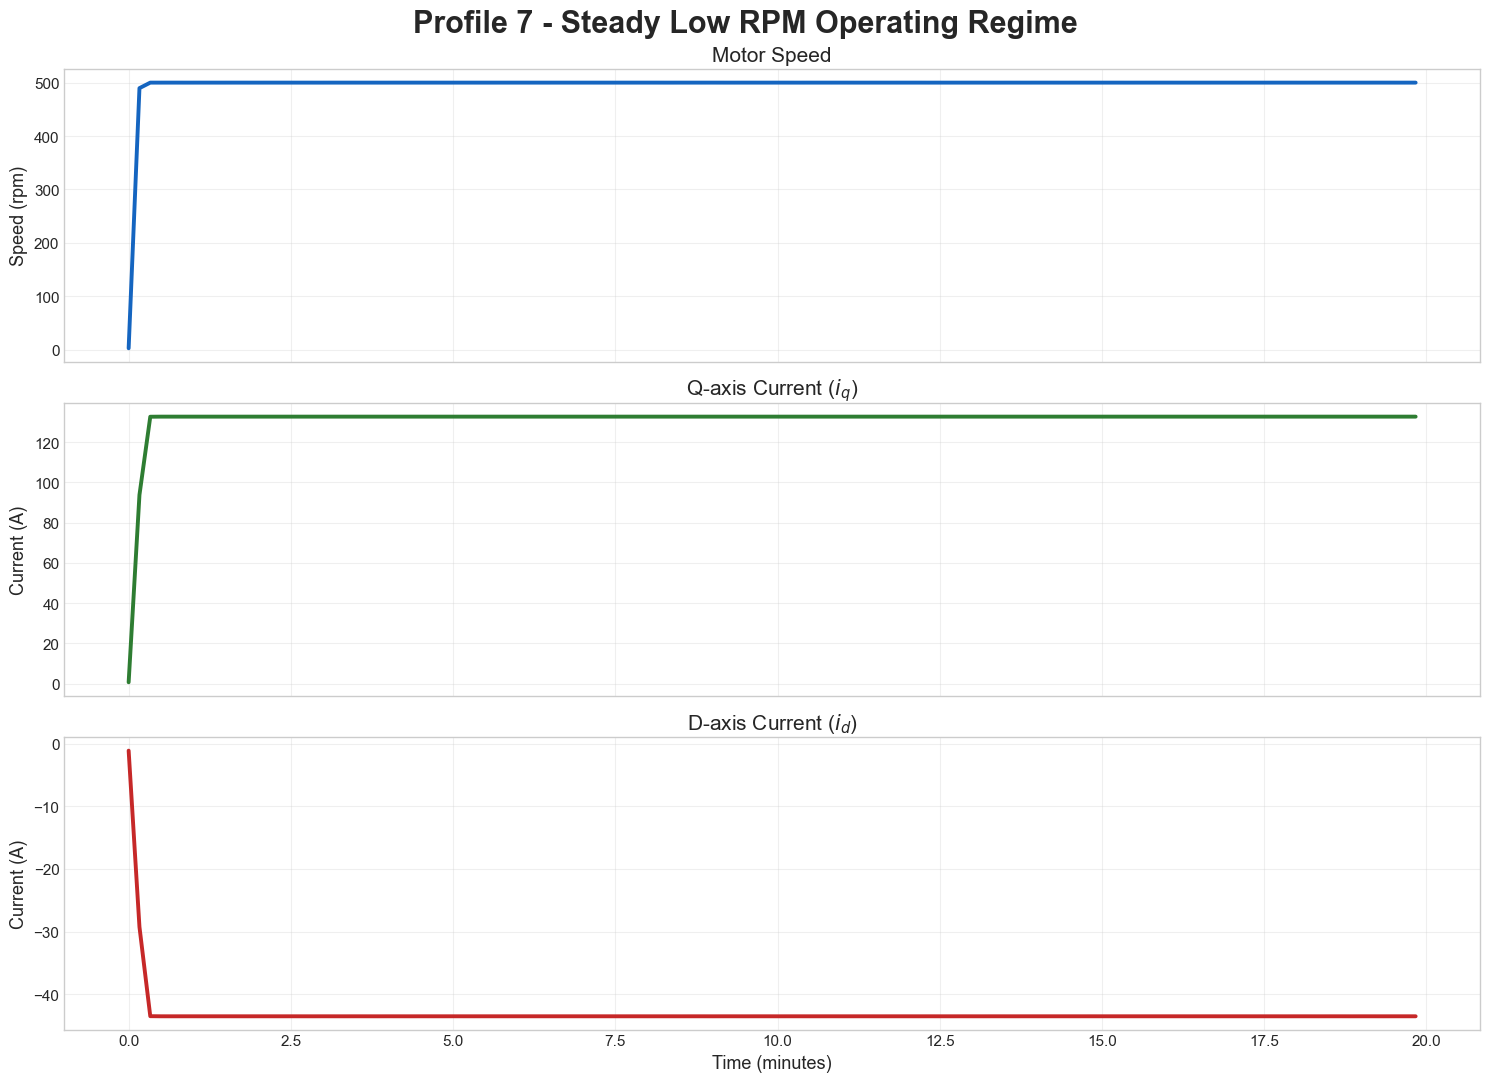

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



PROFILE_ID = 7
WINDOW_MINUTES = 20
DOWNSAMPLE = 20


prof = df[df['profile_id'] == PROFILE_ID].copy()

# 2 Hz dataset
samples_needed = int(WINDOW_MINUTES * 60 * 2)

prof = prof.iloc[:samples_needed]

# downsample for cleaner plotting
prof = prof.iloc[::DOWNSAMPLE]

# time axis in minutes
time = np.arange(len(prof)) * (0.5 * DOWNSAMPLE) / 60



plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15,11),
    sharex=True
)

fig.suptitle(
    "Profile 7 - Steady Low RPM Operating Regime",
    fontsize=22,
    fontweight='bold'
)



axes[0].plot(
    time,
    prof['motor_speed'],
    color='#1565C0',
    linewidth=2.8
)

axes[0].set_title(
    'Motor Speed',
    fontsize=15
)

axes[0].set_ylabel(
    'Speed (rpm)',
    fontsize=13
)


axes[1].plot(
    time,
    prof['i_q'],
    color='#2E7D32',
    linewidth=2.8
)

axes[1].set_title(
    'Q-axis Current ($i_q$)',
    fontsize=15
)

axes[1].set_ylabel(
    'Current (A)',
    fontsize=13
)

# ==============================
# ID CURRENT
# ==============================

axes[2].plot(
    time,
    prof['i_d'],
    color='#C62828',
    linewidth=2.8
)

axes[2].set_title(
    'D-axis Current ($i_d$)',
    fontsize=15
)

axes[2].set_ylabel(
    'Current (A)',
    fontsize=13
)

axes[2].set_xlabel(
    'Time (minutes)',
    fontsize=13
)

# ==============================
# CLEANUP
# ==============================

for ax in axes:

    ax.grid(alpha=0.3)

    ax.tick_params(
        labelsize=11
    )

plt.tight_layout()

plt.show()

### Profile 7 Analysis - Steady Low RPM Operating Regime

Profile 7 represents a **steady-state, low-speed PMSM operating condition** with minimal dynamic variation. The motor speed rapidly increases from rest and stabilizes at approximately **500 rpm**, remaining constant throughout the profile. This indicates a controlled operating point with negligible speed transients after startup.

The **q-axis current ($i_q$)** rises quickly during startup and settles around **132 A**. Since $i_q$ is directly associated with torque production in PMSM operation, this suggests that the motor maintains a nearly constant positive torque demand during the profile.

The **d-axis current ($i_d$)** transitions from near zero to approximately **−43 A** and remains stable thereafter. The negative $i_d$ value indicates operation with **field weakening behaviour** or controlled flux adjustment, although the operating regime itself remains highly steady after the initial transient.

Overall, the profile shows **fast settling behaviour followed by long-duration stable operation** with nearly constant speed and current signals. This makes Profile 7 a useful baseline case for validating PMSM simulation behaviour under **simple, low-dynamic operating conditions** before moving to more challenging profiles involving speed variations, bidirectional torque, or random-walk dynamics.

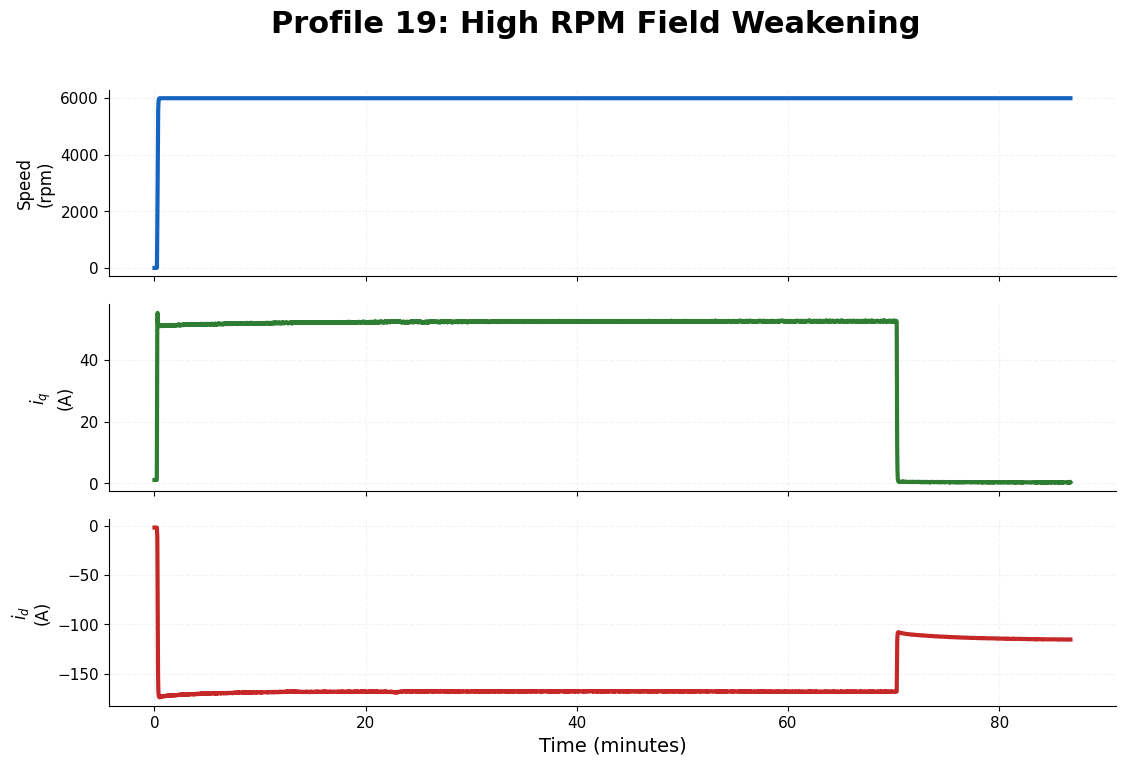

In [37]:
import numpy as np
import matplotlib.pyplot as plt

PROFILE_ID = 19

# ==============================
# LOAD FULL PROFILE
# ==============================

prof = df[df['profile_id']==PROFILE_ID].copy()

# full duration in minutes
time = np.arange(len(prof))*0.5/60

# ==============================
# STYLE
# ==============================

plt.style.use('default')

fig, ax = plt.subplots(
    3,1,
    figsize=(13,8),
    sharex=True
)

fig.suptitle(
    'Profile 19: High RPM Field Weakening',
    fontsize=22,
    fontweight='bold'
)

# ==============================
# SPEED
# ==============================

ax[0].plot(
    time,
    prof['motor_speed'],
    color='#1565C0',
    lw=3
)

ax[0].set_ylabel(
    'Speed\n(rpm)',
    fontsize=12
)

# ==============================
# IQ
# ==============================

ax[1].plot(
    time,
    prof['i_q'],
    color='#2E7D32',
    lw=3
)

ax[1].set_ylabel(
    '$i_q$\n(A)',
    fontsize=12
)

# ==============================
# ID
# ==============================

ax[2].plot(
    time,
    prof['i_d'],
    color='#C62828',
    lw=3
)

ax[2].set_ylabel(
    '$i_d$\n(A)',
    fontsize=12
)

ax[2].set_xlabel(
    'Time (minutes)',
    fontsize=14
)

# ==============================
# CLEANUP
# ==============================

for a in ax:

    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

    a.grid(
        alpha=0.15,
        linestyle='--'
    )

    a.tick_params(
        labelsize=11
    )

plt.subplots_adjust(
    hspace=0.15
)

plt.show()

### Profile 19 Analysis - High RPM Field Weakening Regime

Profile 19 represents a high-speed PMSM operating condition with clear field weakening behaviour. The motor begins from rest and undergoes a rapid acceleration phase, reaching approximately 6000 rpm within about 20–25 seconds before stabilizing at a constant high-speed operating point.

The q-axis current (iq), which controls torque production, rises sharply during acceleration. It briefly overshoots to around 55 A and then settles near 50 A during steady operation. This behaviour is consistent with the increased torque demand required during speed ramp-up followed by reduced torque requirements once the target speed is reached.

The most distinctive feature of this profile is the d-axis current (id). Initially close to zero at low speeds, id becomes strongly negative as motor speed increases, eventually stabilizing near −175 A. This is a characteristic signature of field weakening operation in PMSMs. At high rotational speeds, negative id is intentionally injected to reduce effective air-gap flux and keep the back-EMF within inverter voltage limits.

Overall, Profile 19 captures a classic high-speed PMSM control regime involving startup acceleration, torque regulation, and sustained field weakening operation. Compared with Profile 7, this profile exhibits substantially richer electrical dynamics and provides a more challenging validation case for the digital twin model.

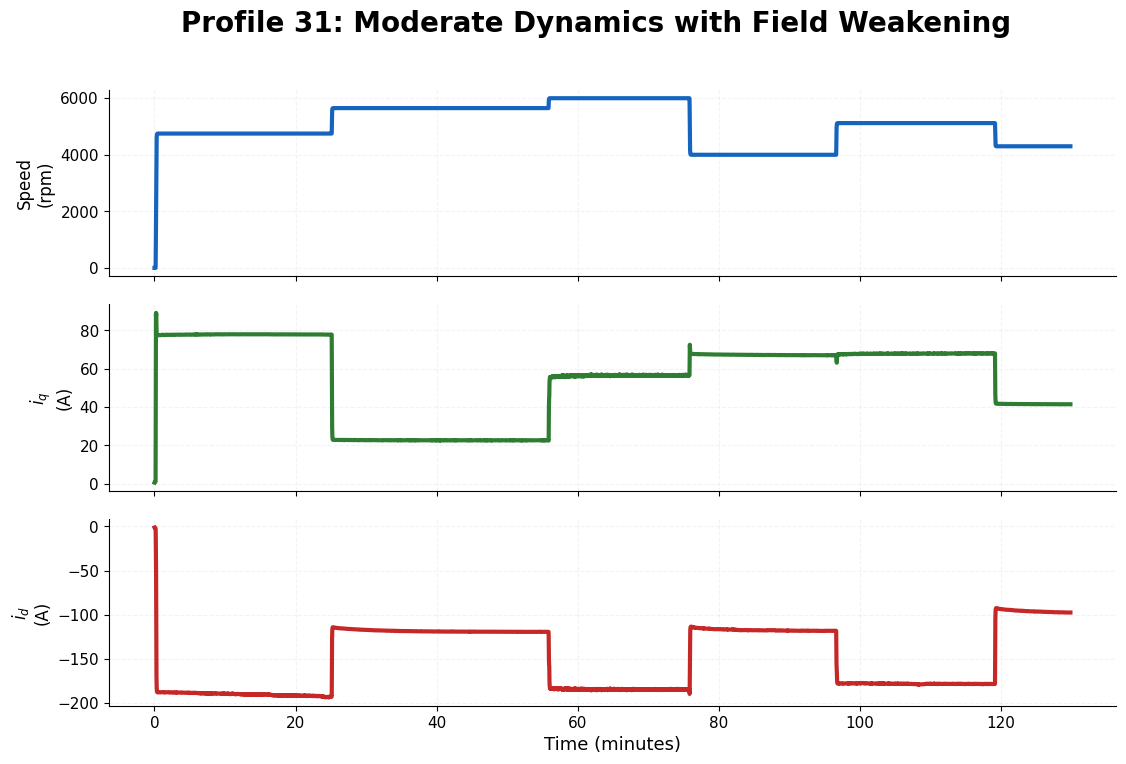

In [36]:
import numpy as np
import matplotlib.pyplot as plt

PROFILE_ID = 31

prof = df[df['profile_id']==PROFILE_ID].copy()

# full profile
time = np.arange(len(prof))*0.5/60

plt.style.use('default')

fig, ax = plt.subplots(
    3,1,
    figsize=(13,8),
    sharex=True
)

fig.suptitle(
    'Profile 31: Moderate Dynamics with Field Weakening',
    fontsize=20,
    fontweight='bold'
)

# SPEED

ax[0].plot(
    time,
    prof['motor_speed'],
    color='#1565C0',
    lw=3
)

ax[0].set_ylabel('Speed\n(rpm)', fontsize=12)

# IQ

ax[1].plot(
    time,
    prof['i_q'],
    color='#2E7D32',
    lw=3
)

ax[1].set_ylabel('$i_q$\n(A)', fontsize=12)

# ID

ax[2].plot(
    time,
    prof['i_d'],
    color='#C62828',
    lw=3
)

ax[2].set_ylabel('$i_d$\n(A)', fontsize=12)
ax[2].set_xlabel('Time (minutes)', fontsize=13)

# CLEANUP

for a in ax:

    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

    a.grid(
        alpha=0.15,
        linestyle='--'
    )

    a.tick_params(
        labelsize=11
    )

plt.subplots_adjust(
    hspace=0.15
)

plt.show()

### Profile 31 Analysis: Moderate Dynamics with Field Weakening

Profile 31 represents a moderately dynamic PMSM operating regime with active field weakening and purely motoring behaviour. Unlike the steady operating profiles, the motor transitions through several distinct speed setpoints during the session, ranging from approximately 4000 rpm to 6000 rpm.

The motor speed exhibits multiple operating regions rather than remaining fixed at a single value. These step changes in speed are accompanied by corresponding adjustments in the electrical control variables, indicating changing operating demands across the profile.

The q-axis current (iq), which governs torque production, adapts to each speed regime. Lower-speed regions generally correspond to lower iq values, while higher operating points require increased q-axis current to sustain the desired operating condition.

The d-axis current (id) remains strongly negative throughout the profile, demonstrating persistent field weakening operation. The magnitude of id varies across speed transitions, reflecting active flux control used to maintain operation within voltage constraints at elevated rotational speeds.

Overall, Profile 31 captures a structured dynamic operating scenario involving multiple speed transitions, coordinated current adaptation, sustained field weakening, and purely motoring behaviour. This makes it a representative validation case for Cluster 3, which contains moderately dynamic field-weakened operating profiles.

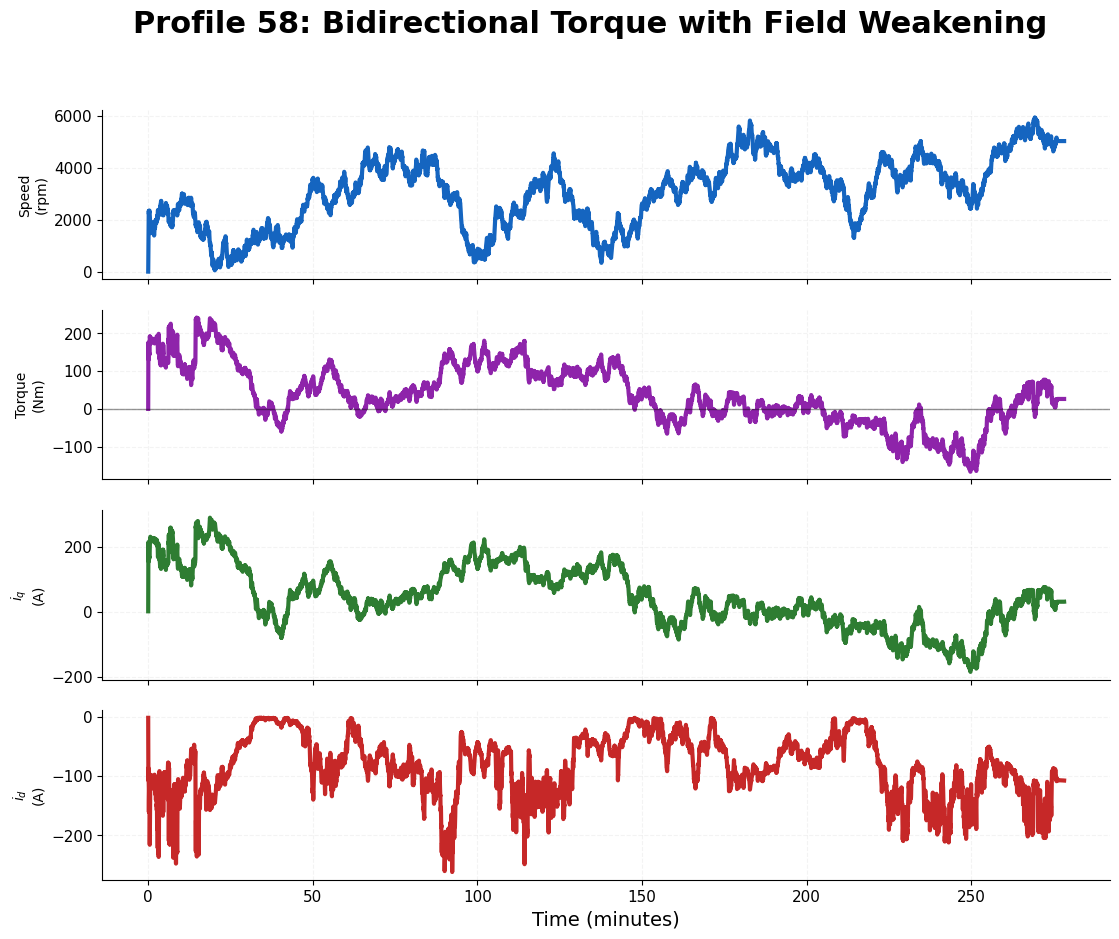

In [39]:
import numpy as np
import matplotlib.pyplot as plt

PROFILE_ID = 58

# ==============================
# LOAD FULL PROFILE
# ==============================

prof = df[df['profile_id']==PROFILE_ID].copy()

time = np.arange(len(prof))*0.5/60

# ==============================
# STYLE
# ==============================

plt.style.use('default')

fig, ax = plt.subplots(
    4,1,
    figsize=(13,10),
    sharex=True
)

fig.suptitle(
    'Profile 58: Bidirectional Torque with Field Weakening',
    fontsize=22,
    fontweight='bold'
)

# ==============================
# SPEED
# ==============================

ax[0].plot(
    time,
    prof['motor_speed'],
    color='#1565C0',
    lw=3
)

ax[0].set_ylabel('Speed\n(rpm)')

# ==============================
# TORQUE
# ==============================

ax[1].plot(
    time,
    prof['torque'],
    color='#8E24AA',
    lw=3
)

ax[1].axhline(
    0,
    color='black',
    lw=1,
    alpha=0.4
)

ax[1].set_ylabel('Torque\n(Nm)')

# ==============================
# IQ
# ==============================

ax[2].plot(
    time,
    prof['i_q'],
    color='#2E7D32',
    lw=3
)

ax[2].set_ylabel('$i_q$\n(A)')

# ==============================
# ID
# ==============================

ax[3].plot(
    time,
    prof['i_d'],
    color='#C62828',
    lw=3
)

ax[3].set_ylabel('$i_d$\n(A)')
ax[3].set_xlabel('Time (minutes)', fontsize=14)

# ==============================
# CLEANUP
# ==============================

for a in ax:

    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

    a.grid(
        alpha=0.15,
        linestyle='--'
    )

    a.tick_params(
        labelsize=11
    )

plt.subplots_adjust(
    hspace=0.18
)

plt.show()

### Profile 58 Analysis: Bidirectional Torque with Field Weakening

Profile 58 represents a dynamic operating regime involving varying speed, bidirectional torque behaviour, and active field weakening.

Unlike the steady-state clusters, the motor speed changes continuously throughout the session, spanning a broad operating range with repeated acceleration and deceleration phases.

The torque signal transitions repeatedly between positive and negative regions, demonstrating both motoring and regenerative operating modes. Correspondingly, the q-axis current (iq) closely follows torque demand, changing sign together with torque direction.

The d-axis current (id) remains predominantly negative throughout the profile, confirming sustained field weakening operation across multiple operating conditions.

Overall, Profile 58 captures a realistic dynamic PMSM operating scenario involving changing speed, bidirectional torque exchange, coordinated current adaptation, and persistent field weakening behaviour, making it a strong representative of Cluster 4.

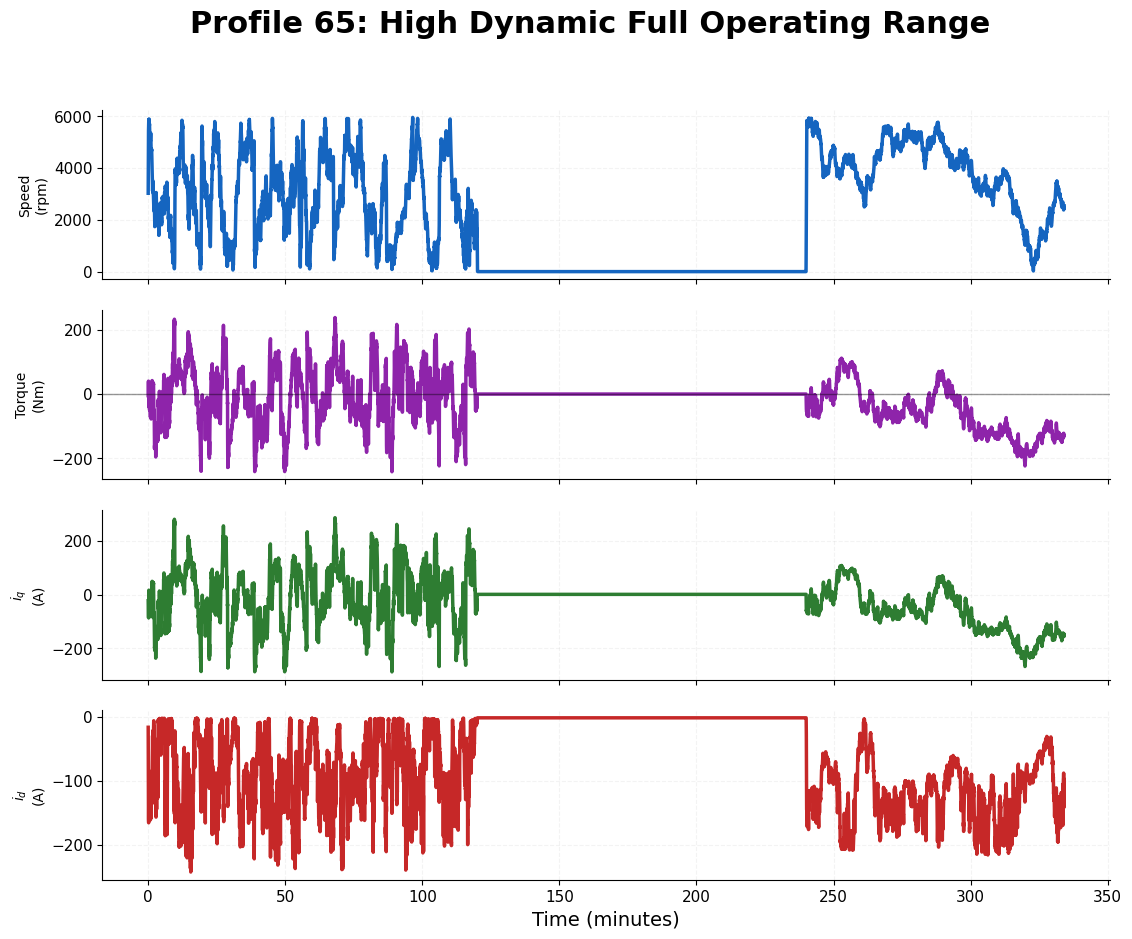

In [43]:
import numpy as np
import matplotlib.pyplot as plt

PROFILE_ID = 65

prof = df[df['profile_id']==PROFILE_ID].copy()

time = np.arange(len(prof))*0.5/60

plt.style.use('default')

fig, ax = plt.subplots(
    4,1,
    figsize=(13,10),
    sharex=True
)

fig.suptitle(
    'Profile 65: High Dynamic Full Operating Range',
    fontsize=22,
    fontweight='bold'
)

ax[0].plot(time, prof['motor_speed'], color='#1565C0', lw=2.5)
ax[0].set_ylabel('Speed\n(rpm)')

ax[1].plot(time, prof['torque'], color='#8E24AA', lw=2.5)
ax[1].axhline(0,color='black',alpha=0.4,lw=1)
ax[1].set_ylabel('Torque\n(Nm)')

ax[2].plot(time, prof['i_q'], color='#2E7D32', lw=2.5)
ax[2].set_ylabel('$i_q$\n(A)')

ax[3].plot(time, prof['i_d'], color='#C62828', lw=2.5)
ax[3].set_ylabel('$i_d$\n(A)')
ax[3].set_xlabel('Time (minutes)', fontsize=14)

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.grid(alpha=0.15, linestyle='--')
    a.tick_params(labelsize=11)

plt.subplots_adjust(hspace=0.18)

plt.show()

### Profile 65 | High Dynamic Full Operating Range

- Highly dynamic operating profile spanning a broad speed range from near 0 rpm to ~6000 rpm  
- Frequent accelerations, decelerations, and irregular operating transitions throughout the session  
- Torque repeatedly changes magnitude and direction, indicating both motoring and regenerative behaviour  
- q-axis current (iq) closely tracks changing torque demand and changes sign across operating modes  
- Strongly varying negative d-axis current (id) indicates sustained field weakening during high-speed operation  
- Represents the most complex operating regime among the chosen representative profiles

## Dataset Summary

| Metric | Value |
|---|---|
| **Total samples** | 1,330,816 |
| **Total profiles** | 69 (after excluding profiles 2 and 3) |
| **Total duration** | 184.8 hours |
| **Sample rate** | 2 Hz (one row = 0.5 seconds) |
| **Profile duration** | 18 min (shortest) to 366 min (longest) |

---

## Excluded Profiles

- **Profile 2 and 3 excluded** — calibration/warmup runs (`speed_mean = 100 rpm`)

---

## Signal Roles

| Category | Variables |
|---|---|
| **Control inputs** | `u_d`, `u_q` |
| **Predict targets** | `i_d`, `i_q`, `motor_speed`, `torque` |
| **PSO parameters** | `coolant`, `ambient`, `pm`, `stator_winding`, `stator_tooth`, `stator_yoke` |

---

## Key Physical Relationships

- **`i_q` vs torque:** perfect linear (`corr = 1.00`) — single scalar multiplier
- **`i_d` vs motor_speed:** nonlinear curve — field weakening, must be modelled
- **`u_q` vs motor_speed:** broad fan — speed depends on both voltage and current
- **`u_d` vs `i_q`:** cross-coupling term — nonlinear, speed-dependent

---

## Operating Space

| Quantity | Description |
|---|---|
| **Speed range** | `-275` to `6000 rpm` (mostly positive, some reverse) |
| **Torque range** | `-246` to `261 Nm` (bidirectional — motoring and braking) |
| **Torque envelope** | triangular — max torque decreases as speed increases |
| **Field weakening** | `i_d` goes strongly negative above ~2000 rpm |

---

## Thermal Behaviour

- **Thermal time constants:** 20–40 minutes
- **Heating order:** `stator_winding > stator_tooth > stator_yoke > pm`
- **pm** is thermally isolated — rises slower, cools slower than stator
- **coolant** actively controls stator temperatures, has limited effect on **pm**
- **ambient** drifts slowly over sessions — treat as background context

---

## Profile Types

- **Step profiles:** discrete constant operating points (`profiles 4, 20, 27`)
- **Random walk:** continuous rapid changes (`profile 53` and similar)

Usage:

- Use **step profiles** for simulator validation
- Use **random walk profiles** for stress testing

---

## Modelling Warnings

1. **Zero-spike in torque and motor_speed** - dataset is imbalanced toward idle
2. **Thermal signals have memory** - cannot treat timesteps independently
3. **Cross-coupling terms are nonlinear** - cannot simplify dq equations
4. **PSO objective must compare full trajectory segments, not single timesteps**
5. **Torque-speed envelope is a hard physical boundary for simulator validation**